# Dansgaard–Oeschger events: bistable climate dynamics

This notebook applies **voila-gp** to the NGRIP δ¹⁸O paleoclimate record (bundled with the original voila package) to estimate the underlying Langevin equation. The vignette in the R package shows that the inferred drift has a *bistable* structure: two stable equilibria around $x \approx -43.5$ and $x \approx -40$ (per mil).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from voila_gp.inference import SDEVI
from voila_gp.init_heuristics import select_diffusion_parameters
from voila_gp.kernels import RQKernel
from voila_gp.prediction import predict_drift, predict_diffusion

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

data = np.load(Path.cwd().parent / 'tests' / 'data' / 'do_events.npz')
x, h = data['x'], float(data['sampling_period'])
print(f'Loaded {x.shape[0]} samples at Δt = {h}')


Loaded 999 samples at Δt = 1.0


## 1. Visualize the paleoclimate record

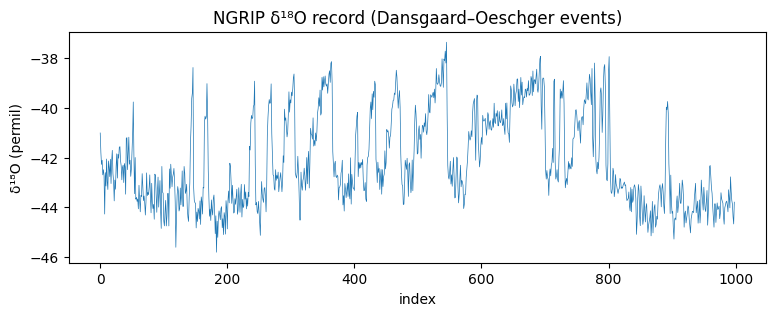

In [2]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(x.shape[0]), x[:, 0], lw=0.5)
ax.set(xlabel='index', ylabel='δ¹⁸O (permil)',
       title='NGRIP δ¹⁸O record (Dansgaard–Oeschger events)')
plt.show()

## 2. Run variational inference

Following the original R vignette: 10 inducing points, RQ kernels for both drift and (log-normal) diffusion, $\varepsilon = 10^{-5}$, prior on diffusion amplitude = 30.

In [3]:
prior_on_sd = 30.0
epsilon = 1e-5
inducing = np.linspace(x.min(), x.max(), 10).reshape(-1, 1)

drift_kernel = RQKernel(amplitude=30.0, alpha=2.0, length_scale=2.0, epsilon=epsilon)
diff_params = select_diffusion_parameters(x, sampling_period=h, prior_on_sd=prior_on_sd)
diff_kernel = RQKernel(
    amplitude=diff_params['kernel_amplitude'], alpha=1.0, length_scale=2.0, epsilon=epsilon
)

fit = SDEVI(drift_kernel=drift_kernel, diff_kernel=diff_kernel)
res = fit.fit(
    time_series=x, sampling_period=h,
    inducing_points=inducing, v_init=diff_params['v'],
    max_iter=20, rel_tol=1e-6, hp_max_iter=200, verbose=False,
)
print(f'Final lower bound L = {res.lower_bound_history[-1]:.4f}')
print(f'Converged: {res.converged} after {res.iterations} iterations.')


Final lower bound L = -1141.3420
Converged: False after 20 iterations.


## 3. Drift and diffusion estimates

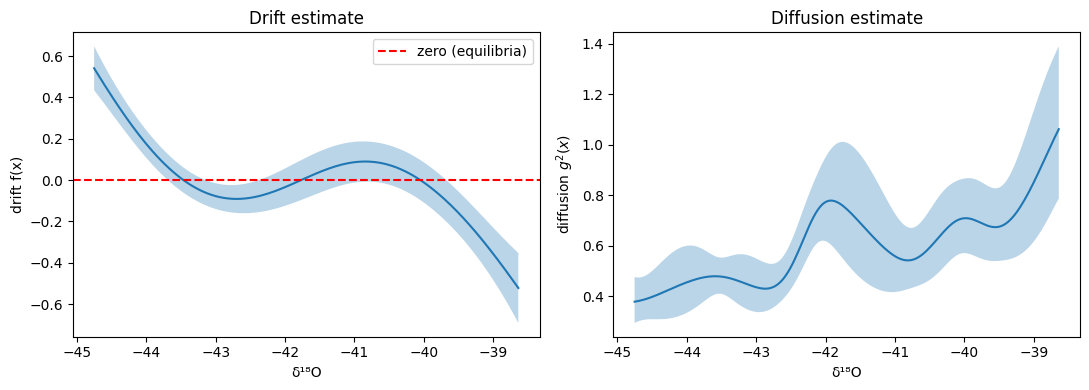

In [4]:
support = np.linspace(np.quantile(x, 0.025), np.quantile(x, 0.975), 200).reshape(-1, 1)

drift_pred = predict_drift(
    kernel=drift_kernel, inducing_points=res.inducing_points,
    posterior_mean=res.f_mean, posterior_cov=res.f_cov, new_x=support,
)
diff_pred = predict_diffusion(
    kernel=diff_kernel, inducing_points=res.inducing_points,
    posterior_mean=res.s_mean, posterior_cov=res.s_cov, new_x=support, v=res.v,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
drift_mu = drift_pred['mean'].detach().numpy()
drift_q  = drift_pred['quantiles'].detach().numpy()
ax1.plot(support, drift_mu)
ax1.fill_between(support.squeeze(), drift_q[:, 0], drift_q[:, 1], alpha=0.3)
ax1.axhline(0, color='r', ls='--', label='zero (equilibria)')
ax1.set(xlabel='δ¹⁸O', ylabel='drift f(x)', title='Drift estimate')
ax1.legend()

diff_mu = diff_pred['mean'].detach().numpy()
diff_q  = diff_pred['quantiles'].detach().numpy()
ax2.plot(support, diff_mu)
ax2.fill_between(support.squeeze(), diff_q[:, 0], diff_q[:, 1], alpha=0.3)
ax2.set(xlabel='δ¹⁸O', ylabel='diffusion $g^2(x)$', title='Diffusion estimate')
plt.tight_layout(); plt.show()


## 4. Locate the equilibria

Stable equilibria are zero crossings of the drift with **negative** slope; unstable equilibria have positive slope. The vignette reports two stable equilibria around $x \approx -43.5$ and $x \approx -40$.

In [5]:
support1d = support.squeeze()
# Find zero crossings
sign_change = np.where(np.sign(drift_mu[:-1]) != np.sign(drift_mu[1:]))[0]
for i in sign_change:
    # Linear interp for x at zero
    x0 = support1d[i] + drift_mu[i] * (support1d[i + 1] - support1d[i]) / (drift_mu[i] - drift_mu[i + 1])
    slope = (drift_mu[i + 1] - drift_mu[i]) / (support1d[i + 1] - support1d[i])
    kind = 'STABLE' if slope < 0 else 'unstable'
    print(f'  zero crossing at x ≈ {x0:.3f}  (slope {slope:+.4f}, {kind})')


  zero crossing at x ≈ -43.463  (slope -0.2471, STABLE)
  zero crossing at x ≈ -41.769  (slope +0.1508, unstable)
  zero crossing at x ≈ -40.050  (slope -0.2267, STABLE)
